# Cómo usar el CNN + BRF sobre los 2D histograms de TESS

Análogo a `Paper_OGLE/How to use the CNN.ipynb`, pero adaptado al pipeline TESS
de este repo:

- Los **2D histograms ya están pre-calculados** en `peaks.parquet`
  (columna `hist2d`, flattened 32×32 = 1024 float32 por fila).
- La **amplitud también está pre-calculada** en `peaks.parquet`
  (columna `amplitude`), por (TIC, sector). No hay que recomputarla
  desde `lightcurves_all.parquet`.
- Cada fila corresponde a un pico `(TIC, sector, source, per, ...)` detectado
  por `select_peaks` en el notebook `2_Github_TESS_variability_MassiveStarG12.ipynb`.
- El **CNN** (Paper_OGLE) recibe imágenes `(N, 32, 32, 1)` y produce probabilidades
  para 8 clases: `['ELL','M','CEP','DST','E','LPV','RR','Rndm']`.
- El **BRF** (Balanced Random Forest) recibe esas 8 probabilidades + `per` +
  `amplitud` y devuelve la clase final.

**Notas importantes**

1. El CNN de Paper_OGLE fue entrenado con `make_2d_histogram(..., norm_max="max")`
   (normalización **lineal** `h/h.max()`). En este repo los `hist2d` están
   normalizados con `log1p(h)/log1p(h.max())`. Si quieres reproducir las predicciones
   del paper exacto hay que **regenerar los hist2d con norm lineal**. Aquí lo dejamos
   tal cual para mostrar el flujo; al final hay una celda opcional para re-normalizar.
2. El CNN espera **magnitudes**; el flux de TESS está en e⁻/s. Por consistencia
   eventual conviene transformar `flux → -2.5·log10(flux/median)` antes de hacer
   el histograma.
3. La columna `amplitude` del parquet se calcula como `flux.max()-flux.min()` por
   `(TIC, sector)` en el notebook previo. Cámbialo a magnitudes si entrenaste
   con magnitudes.

## 1. Imports y rutas

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

PEAKS_PARQUET = "/home/nicolas/nico/git/MassiveStarVariability/peaks.parquet"

# Modelos de Paper_OGLE (pesos del CNN + BRF entrenado)
CNN_WEIGHTS = "/home/nicolas/nico/git/Paper_OGLE/Weights/batchBalanced_Number_M/cp.ckpt"
BRF_PATH    = "/home/nicolas/nico/git/balanced_random_forest_model.joblib"

CLASS_NAMES = ['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR', 'Rndm']

print("TF:", tf.__version__)

TF: 2.13.1


In [55]:
from astroquery.vizier import Vizier
v = Vizier(row_limit=-1)
catalogs = v.get_catalogs("J/A+A/639/A81")
table = catalogs[0]

In [57]:
df_1 = pd.read_csv("catalogs/3_MassiveXTessV8_LC_DeltaMagnitude_Clean.csv")

In [60]:
table.keys()

['Sample',
 'Name',
 'SpType',
 'SpClass',
 'logTeff',
 'logLs',
 'vsini',
 'vmac',
 'Nsp',
 'VarTypesp',
 'VarTypeT',
 'Simbad',
 '_RA',
 '_DE']

In [ ]:
from astropy.table import Table, hstack
from astropy.coordinates import SkyCoord
import astropy.units as u

cat_astropy = Table.from_pandas(df_1[["TIC", "sector_list", "ra", "dec"]])

# Cross-match local con SkyCoord: evita el fallo de XMatch cuando la versión
# instalada de astroquery no reconoce el string "vizier:..." como catálogo remoto.
# `table` ya está cargado en memoria desde la celda anterior.
coords1 = SkyCoord(ra=cat_astropy["ra"].data, dec=cat_astropy["dec"].data, unit="deg")
coords2 = SkyCoord(ra=table["_RA"].data, dec=table["_DE"].data, unit="deg")

idx, d2d, _ = coords1.match_to_catalog_sky(coords2)
mask = d2d < 2 * u.arcsec

result = hstack([cat_astropy[mask], table[idx[mask]]])
result["angDist"] = d2d[mask].to(u.arcsec)
print(f"Coincidencias: {mask.sum()} de {len(cat_astropy)}")
result

In [ ]:
table

Sample,Name,SpType,SpClass,logTeff,logLs,vsini,vmac,Nsp,VarTypesp,VarTypeT,Simbad,_RA,_DE
,,,,log(K),log(Sun),km / s,km / s,,,,,deg,deg
uint8,str11,str21,str15,float32,float32,int16,int16,int16,str8,str12,str6,float64,float64
1,HD 96715,O4,V((f))z,4.66,4.10,59,86,2,---,SLF,Simbad,166.88674,-59.96353
1,HD 46223,O4,V((f)),4.62,4.16,60,91,7,---,SLF+SPB?,Simbad,98.03878,4.82353
1,HD 155913,O4.5,Vn((f)),4.63,3.88,278,--,9,---,SLF+SPB,Simbad,259.10972,-42.66781
1,HD 46150,O5,V((f))z,4.61,4.03,71,94,20,SB1?,SLF,Simbad,97.98134,4.94286
1,HD 90273,ON7,V,4.59,3.95,55,55,1,---,SLF+SPB?,Simbad,155.93523,-57.64209
1,HD 110360,ON7,V,4.59,3.60,96,86,2,SB1,rot?,Simbad,190.55293,-60.65242
1,HD 47839,O7,V,4.58,3.70,43,65,113,SB1,SLF+beta Cep,Simbad,100.24441,9.89576
1,HD 46485,O7,V((f))nz var?,4.55,3.74,322,--,3,SB1?,EB,Simbad,98.46232,4.52545


## 2. Definir la arquitectura del CNN y cargar pesos

Misma arquitectura que `CNN_2dhist_function.make_model()` del repo Paper_OGLE.

In [ ]:
# Arquitectura CNN: msv.classify_brf.make_model (idéntica a
# Paper_OGLE/CNN_2dhist_function). TensorFlow se importa lazy dentro del
# módulo — correr esta celda en el env con TF (CNN_TESS_min).
from msv.classify_brf import make_model

model_softmax = make_model()
model_softmax.load_weights(CNN_WEIGHTS)
model_softmax.summary()


## 3. Cargar BRF

El BRF espera 10 features: las 8 probabilidades de clase + `amplitud` + `per`.

In [ ]:
from msv.classify_brf import load_brf

brf = load_brf(BRF_PATH)
print("BRF features:", list(brf.feature_names_in_))


## 4. Test sobre una estrella

Tomamos el primer pico de una `(TIC, sector)` cualquiera, reconstruimos
el `hist2d` desde el parquet y lo pasamos por el CNN.

In [40]:
TIC, sector = 12647534, 18

peaks_star = pd.read_parquet(
    PEAKS_PARQUET,
    filters=[("TIC", "=", TIC), ("sector", "=", sector)],
)
print(f"Picos para TIC {TIC} sector {sector}: {len(peaks_star)}")
peaks_star.head()

Picos para TIC 12647534 sector 18: 13


,TIC,sector,source,per,power,prominence,width,amplitude,hist2d
0,12647534,18,LS,0.279436,0.049193,0.048081,3.343417,0.040811,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,12647534,18,LS,0.284875,0.380296,0.380295,4.251806,0.040811,"[0.52832085, 0.0, 0.33333334, 0.33333334, 0.0,..."
2,12647534,18,LS,0.289811,0.054572,0.051217,2.906767,0.040811,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,12647534,18,LS,0.770287,0.089226,0.079488,2.888446,0.040811,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,12647534,18,LS,0.807473,0.333013,0.332994,3.954753,0.040811,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.52832085, 0.0, 0.5..."


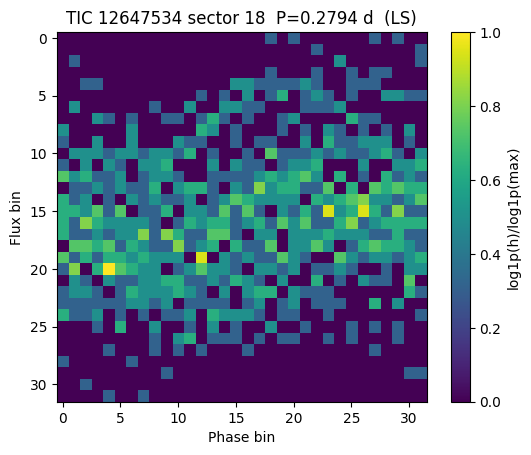

In [41]:
# Reconstruir hist2d: cada fila tiene 1024 floats -> reshape a (32, 32)
row = peaks_star.iloc[0]
H = np.asarray(row["hist2d"], dtype=np.float32).reshape(32, 32)

plt.imshow(H, origin="upper", cmap="viridis")
plt.title(f"TIC {TIC} sector {sector}  P={row['per']:.4f} d  ({row['source']})")
plt.colorbar(label="log1p(h)/log1p(max)")
plt.xlabel("Phase bin")
plt.ylabel("Flux bin")
plt.show()

In [42]:
# Forma esperada por el CNN: (n_examples, 32, 32, 1)
data = H[np.newaxis, ..., np.newaxis]  # (1, 32, 32, 1)
print("shape:", data.shape)

probs = model_softmax.predict(data, verbose=0)
df_probs = pd.DataFrame(probs, columns=CLASS_NAMES)
df_probs

shape: (1, 32, 32, 1)


,ELL,M,CEP,DST,E,LPV,RR,Rndm
0,1.991232e-08,4.029833e-07,0.000007,0.00076,4.289199e-09,0.998441,0.000033,0.000759


## 5. Agregar período + amplitud → BRF

Tanto `per` como `amplitude` vienen directos del parquet (no hay que recalcular
desde la curva de luz).

In [43]:
amp = float(row["amplitude"])
print("amplitud:", amp)

df_brf_in = df_probs.copy()
df_brf_in["amplitud"] = amp
df_brf_in["per"] = float(row["per"])
# Reordenar a las features que espera el BRF
df_brf_in = df_brf_in[list(brf.feature_names_in_)]
df_brf_in

amplitud: 0.040811412036418915


,ELL,M,CEP,DST,E,LPV,RR,Rndm,per,amplitud
0,1.991232e-08,4.029833e-07,0.000007,0.00076,4.289199e-09,0.998441,0.000033,0.000759,0.279436,0.040811


In [44]:
pred = brf.predict(df_brf_in)
prob = brf.predict_proba(df_brf_in)
pred_class = int(pred[0])
print(f"Clase predicha: {CLASS_NAMES[pred_class]}  (prob={prob[0, pred_class]:.4f})")

Clase predicha: RR  (prob=0.3160)


### 5.1 Monte Carlo Dropout (sanity check de incertidumbre)

`model.predict(...)` desactiva los Dropout. Para estimar incertidumbre activamos
el dropout en inferencia llamando al modelo con `training=True` y repetimos
`N_MC` veces. Cada pasada da un vector de 8 probabilidades distinto. Lo pasamos
también por el BRF para ver qué tan estable es la clase final.

In [45]:
N_MC = 500

# Repetimos `data` N_MC veces y llamamos al modelo con training=True para que
# los Dropout queden activos. Una sola llamada en batch es mucho más rápido
# que un loop python.
data_mc = np.repeat(data, N_MC, axis=0)  # (N_MC, 32, 32, 1)
probs_mc = model_softmax(data_mc, training=True).numpy()  # (N_MC, 8)

# BRF sobre cada muestra del CNN
df_mc = pd.DataFrame(probs_mc, columns=CLASS_NAMES)
df_mc["amplitud"] = float(row["amplitude"])
df_mc["per"]      = float(row["per"])
df_mc = df_mc[list(brf.feature_names_in_)]
brf_pred_mc = brf.predict(df_mc)

# Resumen
mean_p = probs_mc.mean(axis=0)
std_p  = probs_mc.std(axis=0)
print("CNN class probabilities (mean ± std sobre {} pasadas):".format(N_MC))
for c, m, s in zip(CLASS_NAMES, mean_p, std_p):
    print(f"  {c:>4}: {m:.3f} ± {s:.3f}")

brf_counts = pd.Series(brf_pred_mc).map(lambda i: CLASS_NAMES[int(i)]).value_counts()
print("\nBRF clases (frecuencia sobre {} pasadas):".format(N_MC))
print(brf_counts.to_string())

CNN class probabilities (mean ± std sobre 500 pasadas):
   ELL: 0.000 ± 0.000
     M: 0.000 ± 0.000
   CEP: 0.000 ± 0.002
   DST: 0.007 ± 0.025
     E: 0.000 ± 0.000
   LPV: 0.989 ± 0.027
    RR: 0.000 ± 0.002
  Rndm: 0.003 ± 0.007

BRF clases (frecuencia sobre 500 pasadas):
RR      417
CEP      52
Rndm     31


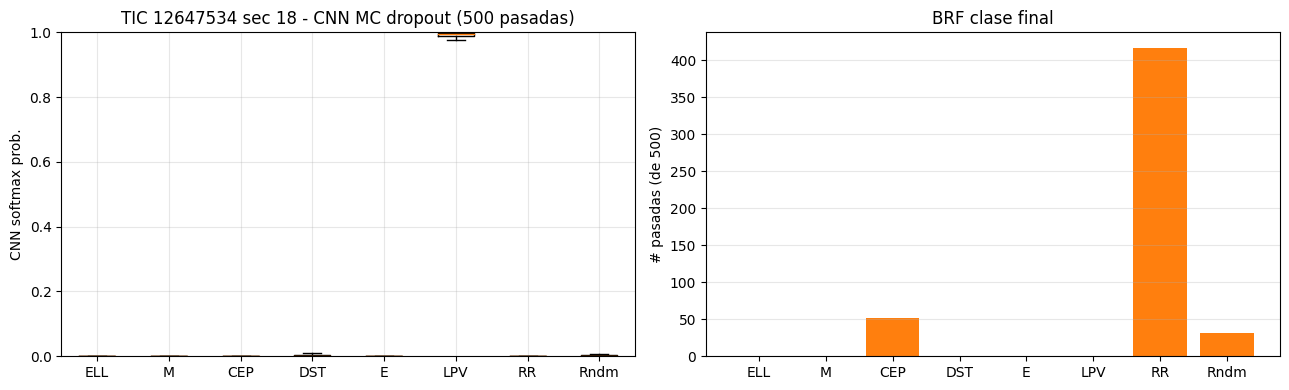

In [46]:
# Plot: distribución de probabilidades CNN por clase + frecuencia de clase BRF
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CNN: boxplot por clase
axes[0].boxplot(
    [probs_mc[:, i] for i in range(len(CLASS_NAMES))],
    labels=CLASS_NAMES, showfliers=False,
)
axes[0].set_ylabel("CNN softmax prob.")
axes[0].set_title(f"TIC {TIC} sec {sector} - CNN MC dropout ({N_MC} pasadas)")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

# BRF: bar plot con conteo de clases
counts = pd.Series(brf_pred_mc).map(lambda i: CLASS_NAMES[int(i)]).value_counts()
counts = counts.reindex(CLASS_NAMES, fill_value=0)
axes[1].bar(counts.index, counts.values, color="C1")
axes[1].set_ylabel(f"# pasadas (de {N_MC})")
axes[1].set_title("BRF clase final")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### 5.2 Todos los peaks de la estrella × todos los trainings del CNN

`Paper_OGLE/Weights/` tiene 7 checkpoints (variantes con/ sin `batchBalanced`,
distintos `Number_X`). Aquí clasificamos **todos los peaks** de `(TIC, sector)`
con **cada training** y comparamos qué dice cada modelo. La arquitectura es la
misma, así que reutilizamos `model_softmax` y solo recargamos pesos.

In [47]:
import os

WEIGHTS_DIR = "/home/nicolas/nico/git/Paper_OGLE/Weights"
TRAININGS = [
    "Number_CEP",
    "Number_DST",
    "Number_ELL",
    "Number_M",
    "batchBalanced_Number_DST",
    "batchBalanced_Number_ELL",
    "batchBalanced_Number_M",
]

# Cubo (n_peaks, 32, 32, 1) con todos los peaks de la estrella
H_all = np.stack(
    [np.asarray(h, dtype=np.float32).reshape(32, 32) for h in peaks_star["hist2d"].values]
)
X_star = H_all[..., np.newaxis]
n_peaks = X_star.shape[0]
print(f"Peaks de TIC {TIC} sec {sector}: {n_peaks}")

# DataFrame largo: (peak_idx, training, brf_class, brf_prob, cnn_top_class, cnn_top_prob)
records = []
cnn_probs_per_training = {}   # training -> (n_peaks, 8) softmax
brf_probs_per_training = {}   # training -> (n_peaks, 8) BRF proba

for tr in TRAININGS:
    ckpt = os.path.join(WEIGHTS_DIR, tr, "cp.ckpt")
    model_softmax.load_weights(ckpt)
    p_cnn = model_softmax.predict(X_star, verbose=0)   # (n_peaks, 8)
    cnn_probs_per_training[tr] = p_cnn

    # BRF input por peak
    df_in = pd.DataFrame(p_cnn, columns=CLASS_NAMES)
    df_in["amplitud"] = peaks_star["amplitude"].to_numpy()
    df_in["per"]      = peaks_star["per"].to_numpy()
    df_in = df_in[list(brf.feature_names_in_)]
    brf_p   = brf.predict(df_in)
    brf_pp  = brf.predict_proba(df_in)
    brf_probs_per_training[tr] = brf_pp

    for i in range(n_peaks):
        cnn_top = int(np.argmax(p_cnn[i]))
        records.append(dict(
            peak_idx       = i,
            per            = float(peaks_star["per"].iloc[i]),
            training       = tr,
            cnn_top_class  = CLASS_NAMES[cnn_top],
            cnn_top_prob   = float(p_cnn[i, cnn_top]),
            brf_class      = CLASS_NAMES[int(brf_p[i])],
            brf_prob       = float(brf_pp[i, int(brf_p[i])]),
        ))

# Restaurar pesos por defecto (CNN_WEIGHTS) por si el orden de TRAININGS cambia
model_softmax.load_weights(CNN_WEIGHTS)

cmp_df = pd.DataFrame(records)
cmp_df.head(len(TRAININGS) * 2)

Peaks de TIC 12647534 sec 18: 13


,peak_idx,per,training,cnn_top_class,cnn_top_prob,brf_class,brf_prob
0,0,0.279436,Number_CEP,LPV,0.987352,RR,0.378
1,1,0.284875,Number_CEP,LPV,0.884536,CEP,0.472
2,2,0.289811,Number_CEP,LPV,0.810756,RR,0.390
3,3,0.770287,Number_CEP,LPV,0.983532,CEP,0.498
4,4,0.807473,Number_CEP,DST,0.980746,CEP,0.516
5,5,0.842328,Number_CEP,LPV,0.768218,CEP,0.642
6,6,1.018119,Number_CEP,LPV,0.675736,CEP,0.750
7,7,0.270834,Number_CEP,Rndm,0.999228,Rndm,1.000
8,8,0.583336,Number_CEP,Rndm,0.989237,Rndm,0.954
9,9,0.854170,Number_CEP,ELL,0.761797,ELL,0.916


In [ ]:
# Visualizar los hist2d de cada peak (contexto)
ncol = min(n_peaks, 6)
nrow = int(np.ceil(n_peaks / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2.5 * nrow), squeeze=False)
for i in range(nrow * ncol):
    ax = axes[i // ncol, i % ncol]
    if i < n_peaks:
        ax.imshow(H_all[i], origin="upper", cmap="viridis")
        ax.set_title(
            f"peak {i}\nP={peaks_star['per'].iloc[i]:.4f} d\n({peaks_star['source'].iloc[i]})",
            fontsize=8,
        )
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"TIC {TIC} sec {sector} — 2D histograms", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla pivot: Y=trainings, X=peak_idx, color=clase BRF
from matplotlib.patches import Patch

class_to_int = {c: i for i, c in enumerate(CLASS_NAMES)}
pivot_class = cmp_df.pivot(index="training", columns="peak_idx", values="brf_class").loc[TRAININGS]
pivot_prob  = cmp_df.pivot(index="training", columns="peak_idx", values="brf_prob").loc[TRAININGS]
class_int_mat = pivot_class.applymap(class_to_int.get).to_numpy()

fig, ax = plt.subplots(figsize=(1.1 * n_peaks + 2, 0.5 * len(TRAININGS) + 1.5))
ax.imshow(class_int_mat, cmap="tab10", vmin=0, vmax=len(CLASS_NAMES) - 1, aspect="auto")
ax.set_xticks(range(n_peaks))
ax.set_xticklabels([f"peak {i}\nP={peaks_star['per'].iloc[i]:.3f}" for i in range(n_peaks)], fontsize=8)
ax.set_yticks(range(len(TRAININGS)))
ax.set_yticklabels(TRAININGS, fontsize=8)
for r in range(len(TRAININGS)):
    for c in range(n_peaks):
        ax.text(c, r,
                f"{pivot_class.iat[r, c]}\n{pivot_prob.iat[r, c]:.2f}",
                ha="center", va="center", fontsize=7, color="white")
ax.set_title(f"BRF class por (peak, training) — TIC {TIC} sec {sector}")
cmap = plt.get_cmap("tab10")
handles = [Patch(color=cmap(class_to_int[c] / (len(CLASS_NAMES) - 1)), label=c) for c in CLASS_NAMES]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="clase")
plt.tight_layout()
plt.show()

## 5.3 Clasificación CNN+BRF para las 16 estrellas del cross-match (J/A+A/639/A81)

Para cada estrella del cross-match cargamos todos sus picos desde `peaks.parquet`,
los pasamos por el CNN (pesos `CNN_WEIGHTS`) y el BRF, y visualizamos:

1. **Heatmap**: BRF class + probabilidad por peak para cada estrella.
2. **Hist2D grids**: imagen fold×flux por cada peak, con la clase predicha.

In [ ]:
import os

N_MC = 20  # pasadas Monte Carlo dropout por peak y training

tic_to_name = {int(t): str(n) for t, n in zip(result["TIC"], result["Name"])}

all_records   = []
peaks_per_tic = {}

for tic, name in tic_to_name.items():
    df_pk = pd.read_parquet(PEAKS_PARQUET, filters=[("TIC", "=", tic)])
    if len(df_pk) == 0:
        print(f"TIC {tic} ({name}): sin picos en peaks.parquet")
        continue
    df_pk = df_pk.reset_index(drop=True)

    H_all = np.stack([np.asarray(h, dtype=np.float32).reshape(32, 32)
                      for h in df_pk["hist2d"].values])
    peaks_per_tic[tic] = (df_pk, H_all)

    n_pk = len(df_pk)
    X = H_all[..., np.newaxis]                          # (n_pk, 32, 32, 1)
    X_mc  = np.repeat(X, N_MC, axis=0)                  # (n_pk*N_MC, 32, 32, 1)
    amp_mc = np.repeat(df_pk["amplitude"].to_numpy(), N_MC)
    per_mc = np.repeat(df_pk["per"].to_numpy(), N_MC)

    for tr in TRAININGS:
        model_softmax.load_weights(os.path.join(WEIGHTS_DIR, tr, "cp.ckpt"))

        # training=True mantiene dropout activo en inferencia
        p_cnn_flat = model_softmax(X_mc, training=True).numpy()   # (n_pk*N_MC, 8)
        p_cnn_mc   = p_cnn_flat.reshape(n_pk, N_MC, 8)            # (n_pk, N_MC, 8)

        # BRF sobre las N_MC pasadas de cada peak en un solo batch
        df_in_mc = pd.DataFrame(p_cnn_flat, columns=CLASS_NAMES)
        df_in_mc["amplitud"] = amp_mc
        df_in_mc["per"]      = per_mc
        df_in_mc = df_in_mc[list(brf.feature_names_in_)]

        brf_pp_flat = brf.predict_proba(df_in_mc)                 # (n_pk*N_MC, 8)
        brf_pp_mc   = brf_pp_flat.reshape(n_pk, N_MC, 8)          # (n_pk, N_MC, 8)

        brf_median = np.median(brf_pp_mc, axis=1)   # (n_pk, 8)
        brf_sigma  = np.std(brf_pp_mc,   axis=1)    # (n_pk, 8)
        brf_pred   = np.argmax(brf_median, axis=1)  # clase ganadora por mediana

        for i in range(n_pk):
            cls_idx = brf_pred[i]
            all_records.append(dict(
                TIC        = tic,
                Name       = name,
                peak_idx   = i,
                per        = float(df_pk["per"].iloc[i]),
                sector     = int(df_pk["sector"].iloc[i]),
                source     = df_pk["source"].iloc[i],
                training   = tr,
                brf_class  = CLASS_NAMES[cls_idx],
                brf_median = float(brf_median[i, cls_idx]),
                brf_sigma  = float(brf_sigma[i, cls_idx]),
            ))

model_softmax.load_weights(CNN_WEIGHTS)
cmp_all = pd.DataFrame(all_records)
print(f"Estrellas: {cmp_all['TIC'].nunique()} | "
      f"Trainings: {cmp_all['training'].nunique()} | "
      f"MC passes por (peak, training): {N_MC} | "
      f"Total registros: {len(cmp_all)}")
cmp_all.head(len(TRAININGS))

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

PDF_HIST2D = "/home/nicolas/nico/git/MassiveStarVariability/cross_match_hist2d.pdf"

with PdfPages(PDF_HIST2D) as pdf:
    for (tic, name), grp in cmp_all.groupby(["TIC", "Name"], sort=False):
        df_pk, H_all = peaks_per_tic[tic]
        n_pk = grp["peak_idx"].nunique()
        ncol = min(n_pk, 6)
        nrow = int(np.ceil(n_pk / ncol))

        fig, axes = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2.5 * nrow), squeeze=False)
        for i in range(nrow * ncol):
            ax = axes[i // ncol, i % ncol]
            if i < n_pk:
                ax.imshow(H_all[i], origin="upper", cmap="viridis")
                ax.set_title(
                    f"peak {i}\nP={df_pk['per'].iloc[i]:.4f}d\n({df_pk['source'].iloc[i]})",
                    fontsize=8,
                )
            ax.set_xticks([]); ax.set_yticks([])
        plt.suptitle(f"{name}  (TIC {tic}) — 2D histograms", y=1.02)
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"-> {PDF_HIST2D}")

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch

PDF_HEATMAP = "/home/nicolas/nico/git/MassiveStarVariability/cross_match_heatmap.pdf"

class_to_int = {c: i for i, c in enumerate(CLASS_NAMES)}
cmap_viz = plt.get_cmap("tab10")

with PdfPages(PDF_HEATMAP) as pdf:
    for (tic, name), grp in cmp_all.groupby(["TIC", "Name"], sort=False):
        n_pk = grp["peak_idx"].nunique()
        per_by_peak = grp.groupby("peak_idx")["per"].first()

        pivot_class  = grp.pivot(index="training", columns="peak_idx", values="brf_class").loc[TRAININGS]
        pivot_median = grp.pivot(index="training", columns="peak_idx", values="brf_median").loc[TRAININGS]
        pivot_sigma  = grp.pivot(index="training", columns="peak_idx", values="brf_sigma").loc[TRAININGS]
        class_int_mat = pivot_class.applymap(class_to_int.get).to_numpy()

        fig, ax = plt.subplots(figsize=(1.1 * n_pk + 2, 0.5 * len(TRAININGS) + 1.5))
        ax.imshow(class_int_mat, cmap="tab10", vmin=0, vmax=len(CLASS_NAMES) - 1, aspect="auto")
        ax.set_xticks(range(n_pk))
        ax.set_xticklabels([f"peak {i}\nP={per_by_peak[i]:.3f}d" for i in range(n_pk)], fontsize=8)
        ax.set_yticks(range(len(TRAININGS)))
        ax.set_yticklabels(TRAININGS, fontsize=8)
        for r in range(len(TRAININGS)):
            for c in range(n_pk):
                ax.text(c, r,
                        f"{pivot_class.iat[r, c]}\n"
                        f"{pivot_median.iat[r, c]:.2f}±{pivot_sigma.iat[r, c]:.2f}",
                        ha="center", va="center", fontsize=7, color="white")
        ax.set_title(f"{name}  (TIC {tic}) — BRF class por (peak, training)  [MC N={N_MC}]")
        handles = [Patch(color=cmap_viz(class_to_int[c] / (len(CLASS_NAMES) - 1)), label=c)
                   for c in CLASS_NAMES]
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="clase")
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"-> {PDF_HEATMAP}")

## 6. Predicción masiva sobre todo `peaks.parquet`

Pasamos todos los picos por el CNN en batch, luego combinamos con `per`
y `amplitude` (ambos ya en el parquet) y corremos el BRF.

In [ ]:
# 6.1 Cargar todos los picos (con amplitude ya incluida)
peaks = pd.read_parquet(
    PEAKS_PARQUET,
    columns=["TIC", "sector", "source", "per", "power", "prominence", "width", "amplitude", "hist2d"],
)
print(f"Total picos: {len(peaks)}")
peaks.head(3)

In [ ]:
# 6.2 Construir el cubo (N, 32, 32, 1) a partir de hist2d
N = len(peaks)
X = np.stack([np.asarray(h, dtype=np.float32) for h in peaks["hist2d"].values])
X = X.reshape(N, 32, 32, 1)
print("cubo:", X.shape, X.dtype)

In [ ]:
# 6.3 CNN predict (en batches para no saturar RAM)
probs_all = model_softmax.predict(X, batch_size=512, verbose=1)
df_probs_all = pd.DataFrame(probs_all, columns=CLASS_NAMES)
df_probs_all.head()

In [ ]:
# 6.4 BRF predict (amplitude y per ya están en `peaks`)
df_brf_all = df_probs_all.copy()
df_brf_all["amplitud"] = peaks["amplitude"].to_numpy()
df_brf_all["per"]      = peaks["per"].to_numpy()
df_brf_all = df_brf_all[list(brf.feature_names_in_)]

# Filtrar NaN antes de predecir
mask_ok = df_brf_all.notna().all(axis=1).to_numpy()
brf_pred  = np.full(len(df_brf_all), -1, dtype=int)
brf_proba = np.full((len(df_brf_all), 8), np.nan, dtype=float)
brf_pred[mask_ok]  = brf.predict(df_brf_all.loc[mask_ok])
brf_proba[mask_ok] = brf.predict_proba(df_brf_all.loc[mask_ok])

In [ ]:
# 6.5 Tabla final: pico + probabilidades CNN + clase BRF
out = peaks[["TIC", "sector", "source", "per", "power", "prominence", "width", "amplitude"]].copy()
for i, c in enumerate(CLASS_NAMES):
    out[f"cnn_{c}"] = probs_all[:, i]
out["brf_class"] = [CLASS_NAMES[c] if c >= 0 else None for c in brf_pred]
out["brf_prob"]  = [brf_proba[i, brf_pred[i]] if brf_pred[i] >= 0 else np.nan for i in range(len(out))]

print("Distribución BRF:")
print(out["brf_class"].value_counts(dropna=False).to_string())
out.head()

In [ ]:
# 6.6 Guardar resultados
OUT_CSV = "/home/nicolas/nico/git/MassiveStarVariability/CNN_BRF_predictions.csv"
out.to_csv(OUT_CSV, index=False)
print("->", OUT_CSV)

## 7. (Opcional) Re-normalizar los hist2d a lineal `h/h.max()`

Si entrenaste el CNN con normalización lineal pero los `hist2d` del parquet están en
`log1p`, esta conversión **no recupera** los valores originales (la información del
número absoluto de eventos por bin se perdió al normalizar). Si quieres comparar con
el modelo original tienes que regenerar el `peaks.parquet` cambiando en
`_phase_fold_hist2d_log` la línea:

```python
h = np.log1p(h) / np.log1p(hmax)   # <- actual
h = h / hmax                       # <- como en Paper_OGLE (norm_max='max')
```

Y volver a correr el bloque de pre-cómputo de picos.